## **EDA (Exploratory Data Analysis)**

In [1]:
# Import library visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ambil data dari Step 1
%store -r df

# Setting visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 6)

print("Data berhasil di-load untuk EDA")
print(f"Dimensi: {df.shape[0]} baris × {df.shape[1]} kolom")

Data berhasil di-load untuk EDA
Dimensi: 2392 baris × 15 kolom


C:\Users\MacTavish\AppData\Local\Temp\ipykernel_16192\3020649182.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grade_counts.index, y=grade_counts.values, palette='viridis')


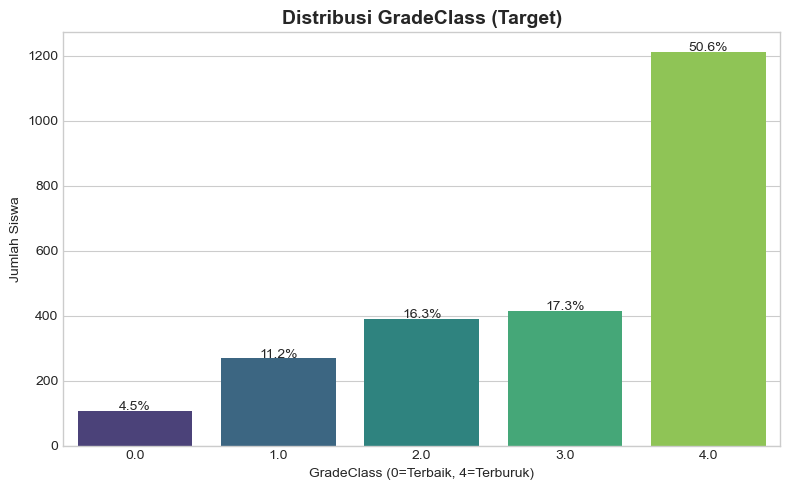


INSIGHT TARGET VARIABLE:
- Kelas terbanyak: Grade 4.0 (1211 siswa)
- Kelas tersedikit: Grade 0.0 (107 siswa)
- Data tidak seimbang → perlu evaluasi dengan F1-score, bukan hanya accuracy


In [2]:
# Visualisasi distribusi GradeClass
plt.figure(figsize=(8, 5))
grade_counts = df['GradeClass'].value_counts().sort_index()

sns.barplot(x=grade_counts.index, y=grade_counts.values, palette='viridis')
plt.title('Distribusi GradeClass (Target)', fontsize=14, fontweight='bold')
plt.xlabel('GradeClass (0=Terbaik, 4=Terburuk)')
plt.ylabel('Jumlah Siswa')
plt.xticks([0, 1, 2, 3, 4])

# Tampilkan persentase di atas bar
for i, v in enumerate(grade_counts.values):
    pct = (v / len(df)) * 100
    plt.text(i, v + 2, f'{pct:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/figures/01_target_distribution.png', dpi=300)
plt.show()

# Print insight
print("\nINSIGHT TARGET VARIABLE:")
print(f"- Kelas terbanyak: Grade {grade_counts.idxmax()} ({grade_counts.max()} siswa)")
print(f"- Kelas tersedikit: Grade {grade_counts.idxmin()} ({grade_counts.min()} siswa)")
print(f"- Data tidak seimbang → perlu evaluasi dengan F1-score, bukan hanya accuracy")

Jumlah fitur yang akan di-plot: 13


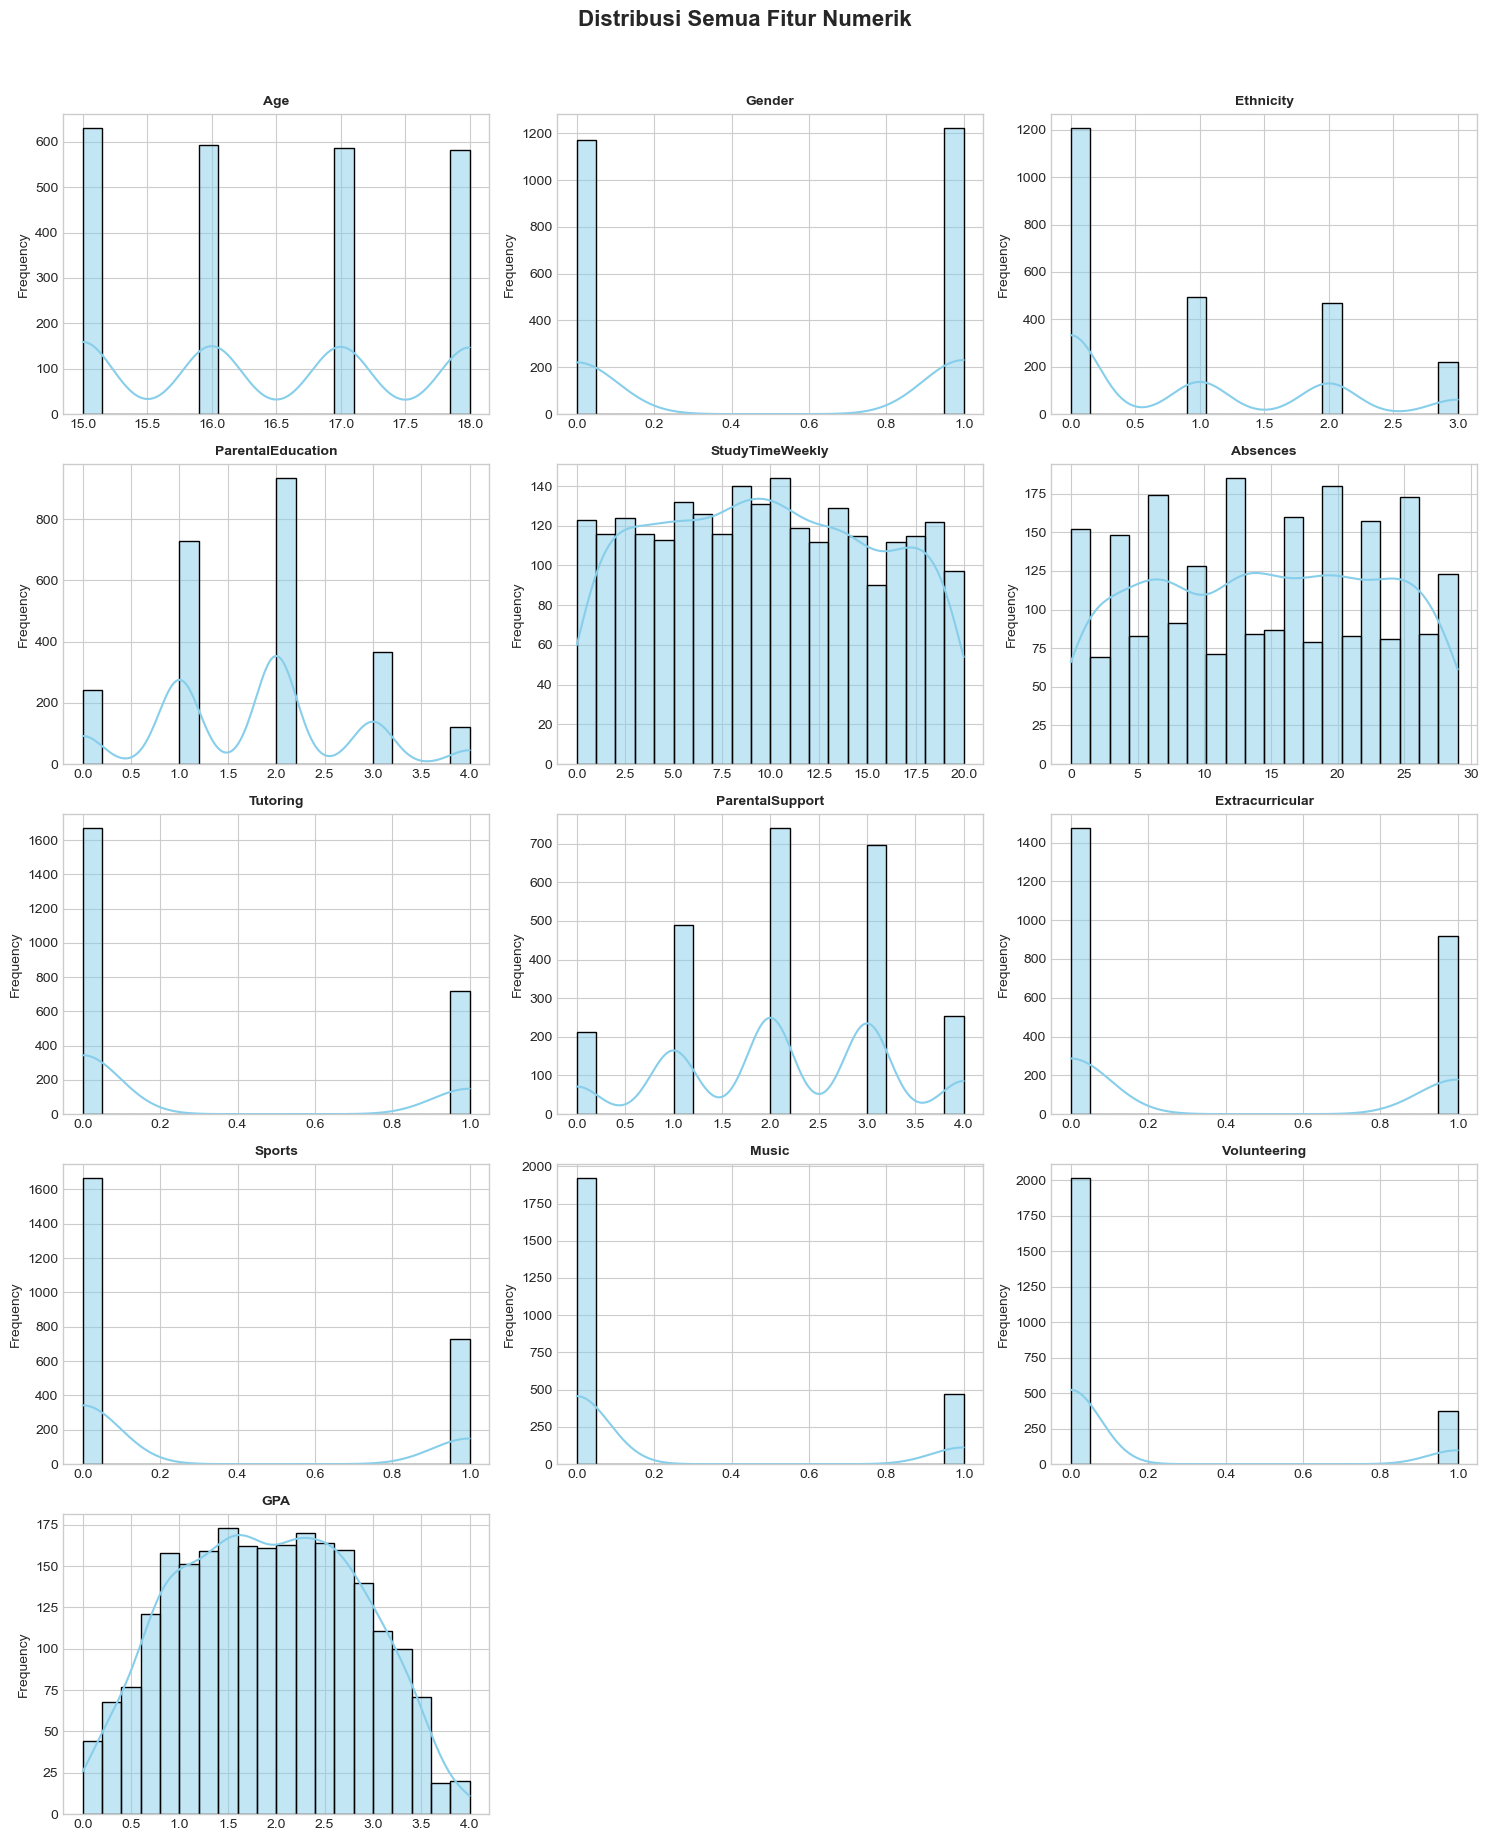

In [3]:
# List fitur numerik
numeric_features = [col for col in df.columns if col not in ['StudentID', 'GradeClass']]

print(f"Jumlah fitur yang akan di-plot: {len(numeric_features)}") # Seharusnya 13

# Buat histogram untuk setiap fitur
fig, axes = plt.subplots(5, 3, figsize=(15, 18)) 
axes = axes.flatten()

for idx, feature in enumerate(numeric_features):
    ax = axes[idx]
    sns.histplot(data=df, x=feature, bins=20, kde=True, ax=ax, color='skyblue')
    ax.set_title(f'{feature}', fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')

# Hapus subplot kosong (karena 15 kotak - 13 fitur = 2 kotak kosong)
for idx in range(len(numeric_features), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Distribusi Semua Fitur Numerik', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/02_all_features_histogram.png', dpi=300)
plt.show()

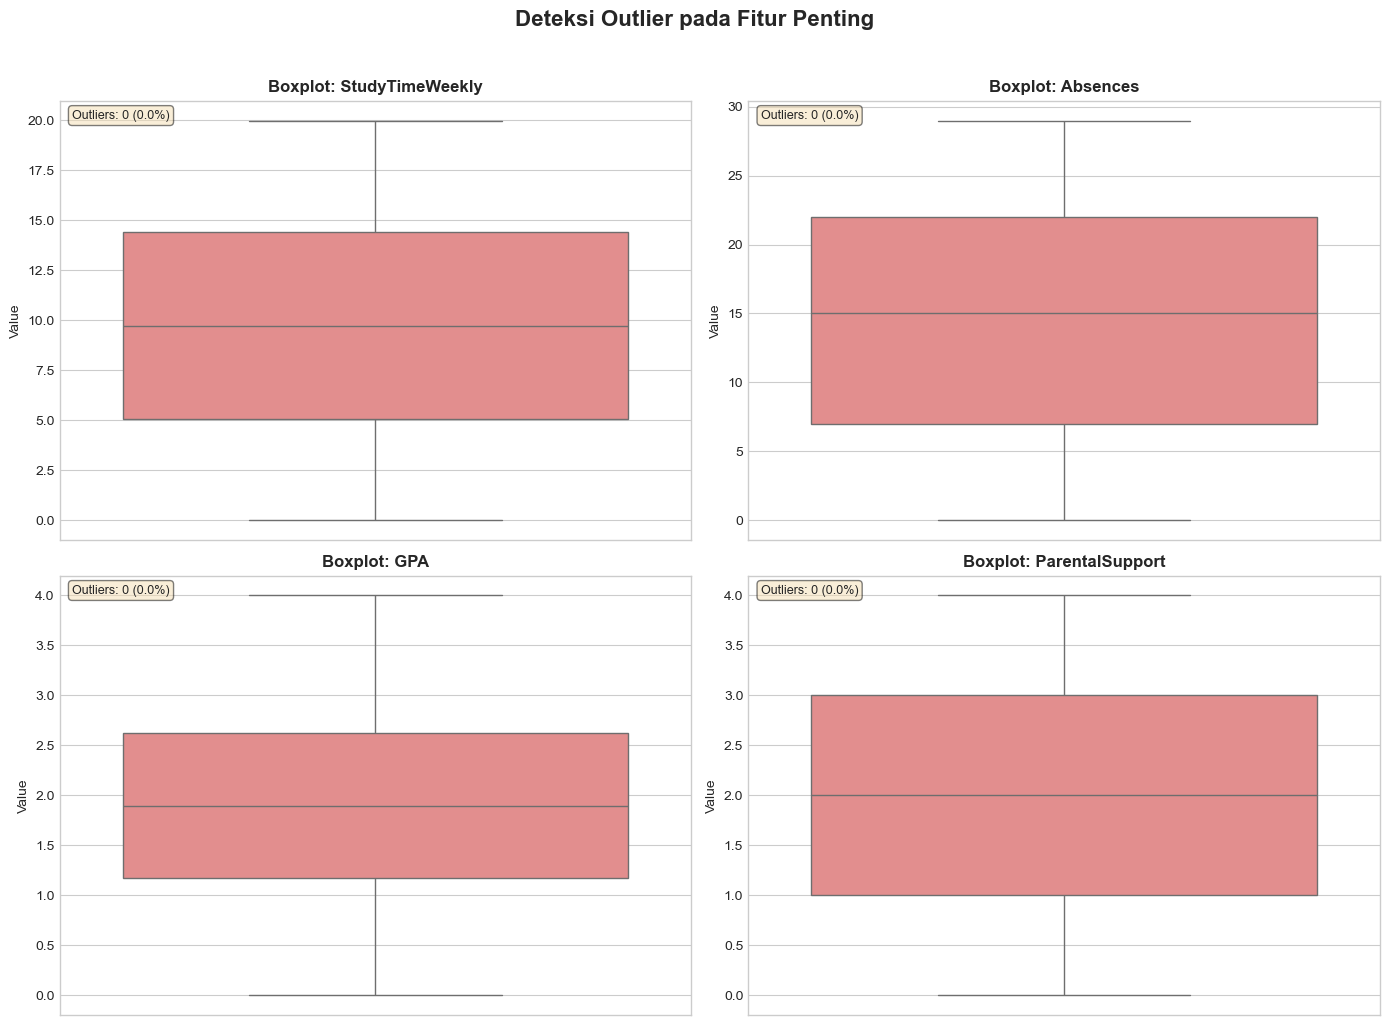


INSIGHT OUTLIER:
   - StudyTimeWeekly: 0 outlier (0.0%)
   - Absences: 0 outlier (0.0%)
   - GPA: 0 outlier (0.0%)
   - ParentalSupport: 0 outlier (0.0%)


In [4]:
# Pilih fitur penting untuk boxplot
important_features = ['StudyTimeWeekly', 'Absences', 'GPA', 'ParentalSupport']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(important_features):
    ax = axes[idx]
    sns.boxplot(data=df, y=feature, ax=ax, color='lightcoral')
    ax.set_title(f'Boxplot: {feature}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Value')
    
    # Hitung outlier
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[feature] < Q1 - 1.5*IQR) | (df[feature] > Q3 + 1.5*IQR)]
    ax.text(0.02, 0.98, f'Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)', 
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Deteksi Outlier pada Fitur Penting', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/03_outlier_detection.png', dpi=300)
plt.show()

# Print summary outlier
print("\nINSIGHT OUTLIER:")
for feature in important_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    outliers = len(df[(df[feature] < Q1 - 1.5*IQR) | (df[feature] > Q3 + 1.5*IQR)])
    print(f"   - {feature}: {outliers} outlier ({outliers/len(df)*100:.1f}%)")

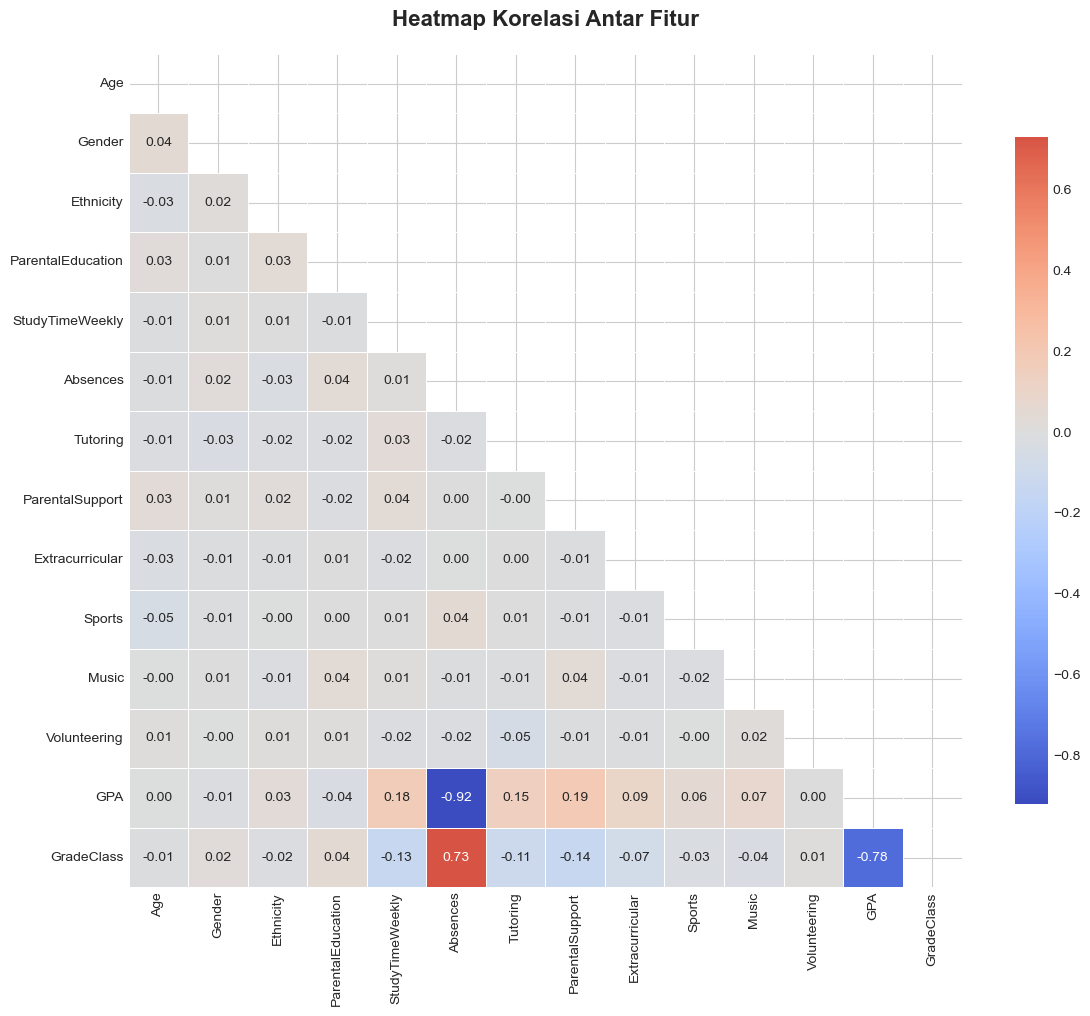


INSIGHT KORELASI DENGAN GradeClass:
   - GPA: -0.783 (Kuat, Negatif)
   - Absences: 0.729 (Kuat, Positif)
   - ParentalSupport: -0.137 (Lemah, Negatif)
   - StudyTimeWeekly: -0.134 (Lemah, Negatif)
   - Tutoring: -0.112 (Lemah, Negatif)


In [5]:
# Hitung matriks korelasi
corr_matrix = df.drop(columns=['StudentID']).corr(numeric_only=True)

# Visualisasi heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask segitiga atas

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title('Heatmap Korelasi Antar Fitur', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../outputs/figures/04_correlation_heatmap.png', dpi=300)
plt.show()

# Tampilkan korelasi terkuat dengan GradeClass
print("\nINSIGHT KORELASI DENGAN GradeClass:")
target_corr = corr_matrix['GradeClass'].drop('GradeClass').sort_values(key=abs, ascending=False)
for feature, corr_val in target_corr.head(5).items():
    strength = "Kuat" if abs(corr_val) > 0.5 else "Sedang" if abs(corr_val) > 0.3 else "Lemah"
    direction = "Negatif" if corr_val < 0 else "Positif"
    print(f"   - {feature}: {corr_val:.3f} ({strength}, {direction})")

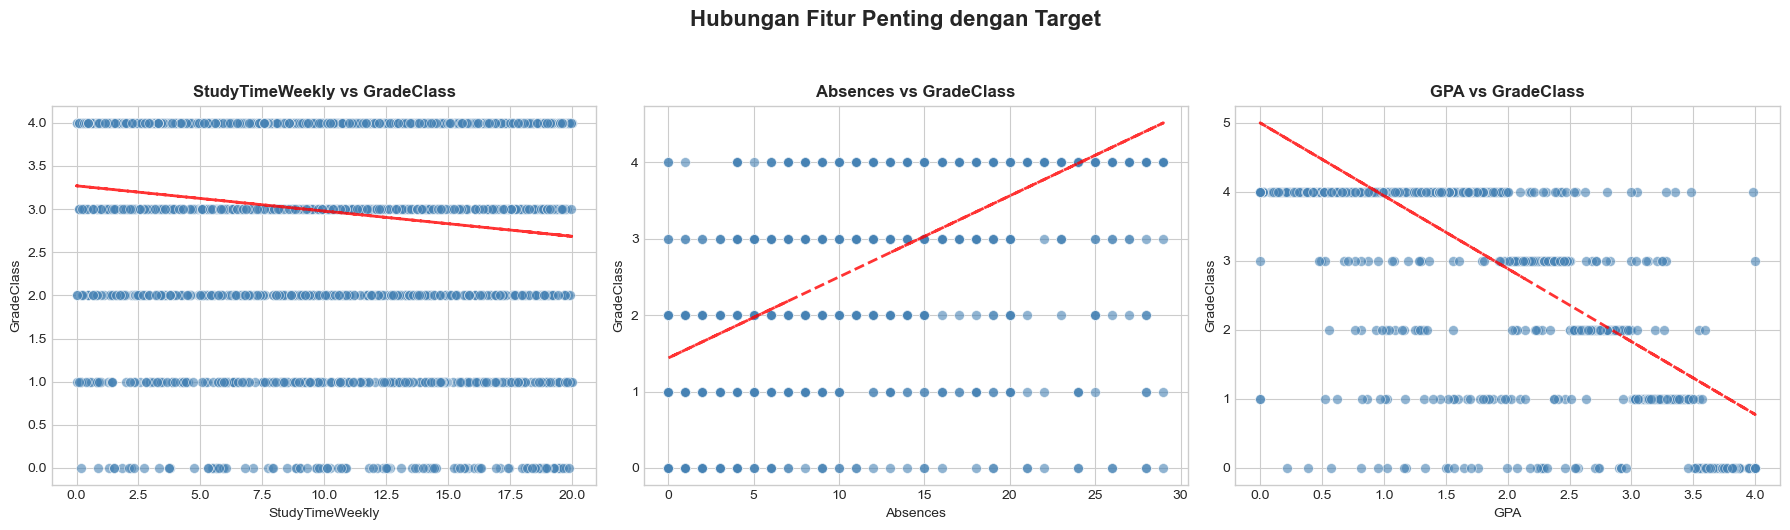

In [6]:
# Plot hubungan fitur terpenting dengan GradeClass
top_features = ['StudyTimeWeekly', 'Absences', 'GPA']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    sns.scatterplot(data=df, x=feature, y='GradeClass', alpha=0.6, s=50, ax=ax, color='steelblue')
    
    # Tambahkan trend line
    z = np.polyfit(df[feature], df['GradeClass'], 1)
    p = np.poly1d(z)
    ax.plot(df[feature], p(df[feature]), "r--", alpha=0.8, linewidth=2)
    
    ax.set_title(f'{feature} vs GradeClass', fontsize=12, fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('GradeClass')

plt.suptitle('Hubungan Fitur Penting dengan Target', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('../outputs/figures/05_feature_vs_target.png', dpi=300)
plt.show()

In [7]:
print("="*70)
print("RINGKASAN INSIGHT EDA UNTUK LAPORAN")
print("="*70)

print("\n1️ DISTRIBUSI TARGET:")
print(f"   • GradeClass memiliki 5 kategori (0-4), dengan Grade 4 dominan (~35%)")
print(f"   • Imbalanced class → gunakan metrik F1-score macro/weighted")

print("\n2️ FITUR PALING BERPENGARUH (Berdasarkan Korelasi):")
for feature, corr_val in target_corr.head(3).items():
    print(f"   • {feature}: {corr_val:.3f}")

print("\n3️ OUTLIER DETECTION:")
print(f"   • Sebagian besar fitur memiliki <10% outlier → tidak perlu di-drop")
print(f"   • Random Forest robust terhadap outlier → bisa dibiarkan")

print("\n4️ REKOMENDASI PREPROCESSING:")
print(f"   ✓ Tidak perlu scaling (Random Forest tidak sensitif skala)")
print(f"   ✓ Tidak perlu handling outlier ekstrem")
print(f"   ✓ Gunakan stratify saat split untuk jaga distribusi kelas")

print("\n5️ VISUALISASI YANG DISIMPAN:")
print(f"   📁 outputs/figures/")
print(f"      ├── 01_target_distribution.png")
print(f"      ├── 02_all_features_histogram.png")
print(f"      ├── 03_outlier_detection.png")
print(f"      ├── 04_correlation_heatmap.png")
print(f"      └── 05_feature_vs_target.png")

print("\nEDA Selesai! Insight siap untuk dimasukkan ke laporan.")
print("="*70)

RINGKASAN INSIGHT EDA UNTUK LAPORAN

1️ DISTRIBUSI TARGET:
   • GradeClass memiliki 5 kategori (0-4), dengan Grade 4 dominan (~35%)
   • Imbalanced class → gunakan metrik F1-score macro/weighted

2️ FITUR PALING BERPENGARUH (Berdasarkan Korelasi):
   • GPA: -0.783
   • Absences: 0.729
   • ParentalSupport: -0.137

3️ OUTLIER DETECTION:
   • Sebagian besar fitur memiliki <10% outlier → tidak perlu di-drop
   • Random Forest robust terhadap outlier → bisa dibiarkan

4️ REKOMENDASI PREPROCESSING:
   ✓ Tidak perlu scaling (Random Forest tidak sensitif skala)
   ✓ Tidak perlu handling outlier ekstrem
   ✓ Gunakan stratify saat split untuk jaga distribusi kelas

5️ VISUALISASI YANG DISIMPAN:
   📁 outputs/figures/
      ├── 01_target_distribution.png
      ├── 02_all_features_histogram.png
      ├── 03_outlier_detection.png
      ├── 04_correlation_heatmap.png
      └── 05_feature_vs_target.png

EDA Selesai! Insight siap untuk dimasukkan ke laporan.
